# 06. 변수 조합 검토 및 최종 모델 튜닝

`05_modeling.ipynb`에서는 기준 회귀 모델 비교, 시간/랜덤 분할 비교, 가격대별 오차 확인, log-price 실험, 변수 중요도 확인을 수행했다.

이 노트북에서는 04까지의 결과로 얻은 데이터셋과 05의 결과를 바탕으로 1차 모델 최종화 실험을 수행한다.

- 변수 조합을 비교하여 최종 입력 변수 구성을 검토한다.
- 성능이 좋았던 트리 기반 앙상블 모델을 대상으로 하이퍼파라미터를 탐색한다.
- 최종 모델의 성능과 변수 중요도를 확인한다.

## 1. 라이브러리 및 경로 설정

검증 세트에서 변수 조합과 하이퍼파라미터를 선택하고, 테스트 세트는 최종 성능 확인에만 사용한다.

In [ ]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(PROJECT_ROOT / '.cache'))
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count() or 1))
(PROJECT_ROOT / '.matplotlib').mkdir(exist_ok=True)
(PROJECT_ROOT / '.cache').mkdir(exist_ok=True)
(PROJECT_ROOT / 'reports').mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

FEATURE_DATA_PATH = PROJECT_ROOT / 'data/processed/seoul_apt_trade_2025_features.csv'
MODELING_DATA_PATH = PROJECT_ROOT / 'data/processed/modeling_dataset.csv'

FEATURE_SET_SCORE_PATH = PROJECT_ROOT / 'reports/06_feature_set_scores.csv'
TUNING_RESULT_PATH = PROJECT_ROOT / 'reports/06_model_tuning_results.csv'
FINAL_SCORE_PATH = PROJECT_ROOT / 'reports/06_final_model_scores.csv'
FINAL_IMPORTANCE_PATH = PROJECT_ROOT / 'reports/06_final_model_feature_importance.csv'
FINAL_FIGURE_DIR = PROJECT_ROOT / 'reports/figures'
FINAL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_ITER = 12

FEATURE_DATA_PATH, MODELING_DATA_PATH


## 2. 데이터 로드

변수 조합을 비교하려면 05에서 제외했던 후보 변수도 필요할 수 있으므로 `seoul_apt_trade_2025_features.csv`를 우선 사용한다. 해당 파일이 없으면 `modeling_dataset.csv`를 사용하되, 이 경우 05에서 이미 선택한 변수 조합만 평가할 수 있다.

In [47]:
if FEATURE_DATA_PATH.exists():
    source_df = pd.read_csv(FEATURE_DATA_PATH, encoding='utf-8-sig')
    source_name = FEATURE_DATA_PATH.name
elif MODELING_DATA_PATH.exists():
    source_df = pd.read_csv(MODELING_DATA_PATH, encoding='utf-8-sig')
    source_name = MODELING_DATA_PATH.name
else:
    raise FileNotFoundError('모델 정제에 필요한 CSV가 없습니다. 03 또는 05 노트북을 먼저 실행하세요.')

source_df['contract_date'] = pd.to_datetime(source_df['contract_date'])
source_df = source_df.sort_values('contract_date').reset_index(drop=True)

print(f'loaded: {source_name}')
source_df.shape

loaded: seoul_apt_trade_2025_features.csv


(77359, 31)

## 3. 후보 변수 조합 정의

05의 기본 변수 조합을 기준으로 삼고, 중복 가능성이 있는 시간/연식 변수와 업무지구 변수를 조정한 조합을 비교한다.
변수 조합 비교는 목적이 다른 두 실험으로 분리한다.

`price_per_m2_10k_krw`는 거래금액을 직접 포함하는 파생 변수이므로 모든 조합에서 제외한다.

### 3-A. 시간/연식 변수 조합

05의 기본 변수 조합(`current_05`)을 기준으로, 단일 연도 자료에서 정보량이 낮거나
중복 가능성이 있는 시간/연식 변수를 조정한 조합을 비교한다.

In [48]:
target_col = 'price_10k_krw'

feature_sets_time = {
    'current_05': {
        'description': '05_modeling.ipynb와 동일한 기본 입력 변수 조합',
        'numeric': [
            'area_m2',
            'floor',
            'built_year',
            'age',
            'contract_year',
            'contract_month',
            'contract_day',
            'distance_to_cbd_km',
            'distance_to_ybd_km',
            'distance_to_gbd_km',
            'nearest_subway_distance_km',
            'nearest_hospital_distance_km',
            'large_mart_count_within_1km',
        ],
        'categorical': ['gu', 'law_dong'],
    },
    'reduced_time_age': {
        'description': '단일 연도 자료에서 정보량이 낮은 contract_year와 중복 가능성이 있는 built_year, contract_day를 제외',
        'numeric': [
            'area_m2',
            'floor',
            'age',
            'contract_month',
            'distance_to_cbd_km',
            'distance_to_ybd_km',
            'distance_to_gbd_km',
            'nearest_subway_distance_km',
            'nearest_hospital_distance_km',
            'large_mart_count_within_1km',
        ],
        'categorical': ['gu', 'law_dong'],
    },
    'access_expanded': {
        'description': '05 기본 조합에 반경 1km 병원 수를 추가하여 접근성 정보를 확장',
        'numeric': [
            'area_m2',
            'floor',
            'built_year',
            'age',
            'contract_month',
            'distance_to_cbd_km',
            'distance_to_ybd_km',
            'distance_to_gbd_km',
            'nearest_subway_distance_km',
            'hospital_count_within_1km',
            'nearest_hospital_distance_km',
            'large_mart_count_within_1km',
        ],
        'categorical': ['gu', 'law_dong'],
    },
}

available_feature_sets_time = {}
for name, config in feature_sets_time.items():
    required = [target_col, 'contract_date', *config['numeric'], *config['categorical']]
    missing = [col for col in required if col not in source_df.columns]
    if missing:
        print(f'skip {name}: missing {missing}')
    else:
        available_feature_sets_time[name] = config

pd.DataFrame([
    {
        'feature_set': name,
        'description': config['description'],
        'numeric_count': len(config['numeric']),
        'categorical_count': len(config['categorical']),
    }
    for name, config in available_feature_sets_time.items()
])

,feature_set,description,numeric_count,categorical_count
0,current_05,05_modeling.ipynb와 동일한 기본 입력 변수 조합,13,2
1,reduced_time_age,단일 연도 자료에서 정보량이 낮은 contract_year와 중복 가능성이 있는 b...,10,2
2,access_expanded,05 기본 조합에 반경 1km 병원 수를 추가하여 접근성 정보를 확장,12,2


### 3-B. 위치 변수 구조 조합

`current_05`를 기준선으로 삼고, 거리 변수와 행정구역 변수의 구성을 달리한 조합을 비교한다.
두 변수군이 담는 위치 정보의 독립성과 중복 정도를 확인하는 것이 목적이다.

In [49]:
feature_sets_location = {
    'current_05': feature_sets_time['current_05'],
    'nearest_business_district': {
        'description': '업무지구별 거리 3개 대신 가장 가까운 업무지구 거리와 업무지구 코드를 사용',
        'numeric': [
            'area_m2',
            'floor',
            'age',
            'contract_month',
            'nearest_business_district_distance_km',
            'nearest_subway_distance_km',
            'nearest_hospital_distance_km',
            'large_mart_count_within_1km',
        ],
        'categorical': ['gu', 'law_dong', 'nearest_business_district'],
    },
    'no_distance': {
        'description': '거리 변수를 모두 제외하고 구/동 범주형 변수만으로 위치 정보를 표현',
        'numeric': [
            'area_m2',
            'floor',
            'age',
            'contract_month',
            'large_mart_count_within_1km',
        ],
        'categorical': ['gu', 'law_dong'],
    },
    'no_region': {
        'description': '구/동 범주형 변수를 제외하고 거리 변수만으로 위치 정보를 표현',
        'numeric': [
            'area_m2',
            'floor',
            'age',
            'contract_month',
            'distance_to_cbd_km',
            'distance_to_ybd_km',
            'distance_to_gbd_km',
            'nearest_subway_distance_km',
            'nearest_hospital_distance_km',
            'large_mart_count_within_1km',
        ],
        'categorical': [],
    },
    'no_region_nearest_bd': {
        'description': '구/동을 제외하고 업무지구 거리는 가장 가까운 1개만 사용하여 거리 변수를 단순화',
        'numeric': [
            'area_m2',
            'floor',
            'age',
            'contract_month',
            'nearest_business_district_distance_km',
            'nearest_subway_distance_km',
            'nearest_hospital_distance_km',
            'large_mart_count_within_1km',
        ],
        'categorical': ['nearest_business_district'],
    },
}

available_feature_sets_location = {}
for name, config in feature_sets_location.items():
    required = [target_col, 'contract_date', *config['numeric'], *config['categorical']]
    missing = [col for col in required if col not in source_df.columns]
    if missing:
        print(f'skip {name}: missing {missing}')
    else:
        available_feature_sets_location[name] = config

pd.DataFrame([
    {
        'feature_set': name,
        'description': config['description'],
        'numeric_count': len(config['numeric']),
        'categorical_count': len(config['categorical']),
    }
    for name, config in available_feature_sets_location.items()
])

,feature_set,description,numeric_count,categorical_count
0,current_05,05_modeling.ipynb와 동일한 기본 입력 변수 조합,13,2
1,nearest_business_district,업무지구별 거리 3개 대신 가장 가까운 업무지구 거리와 업무지구 코드를 사용,8,3
2,no_distance,거리 변수를 모두 제외하고 구/동 범주형 변수만으로 위치 정보를 표현,5,2
3,no_region,구/동 범주형 변수를 제외하고 거리 변수만으로 위치 정보를 표현,10,0
4,no_region_nearest_bd,구/동을 제외하고 업무지구 거리는 가장 가까운 1개만 사용하여 거리 변수를 단순화,8,1


## 4. 평가 함수와 기준 모델 정의

05에서 가장 성능이 좋았던 `RandomForestRegressor`와 `ExtraTreesRegressor`만 변수 조합 비교 대상으로 사용한다. log-price 실험은 05에서 이미 수행했으므로 이 노트북에서는 원가격 예측 기준으로 최종 모델을 정리한다.

In [50]:
def evaluate_regression(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
    }


def make_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='median'), numeric_features),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
            ]), categorical_features),
        ],
        remainder='drop',
    )


def make_model(model_name, numeric_features, categorical_features, params=None):
    params = {} if params is None else params
    preprocessor = make_preprocessor(numeric_features, categorical_features)
    if model_name == 'random_forest':
        estimator = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    elif model_name == 'extra_trees':
        estimator = ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    else:
        raise ValueError(f'Unknown model: {model_name}')
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', estimator),
    ])

# 05_modeling.ipynb의 기준 모델과 동일한 초기 파라미터
baseline_params = {
    'n_estimators': 120,
    'max_depth': 18,
    'min_samples_leaf': 3,
}


def make_baseline_models(numeric_features, categorical_features):
    return {
        'random_forest': make_model('random_forest', numeric_features, categorical_features, baseline_params),
        'extra_trees': make_model('extra_trees', numeric_features, categorical_features, baseline_params),
    }


def make_modeling_df(config):
    columns = [target_col, 'contract_date', *config['numeric'], *config['categorical']]
    result = source_df[columns].copy()
    result = result.dropna(subset=[target_col, *config['numeric'], *config['categorical']]).copy()
    result = result.sort_values('contract_date').reset_index(drop=True)
    return result


def split_train_valid_test(df):
    train_end = pd.Timestamp('2025-09-01')
    valid_end = pd.Timestamp('2025-11-01')
    train_df = df[df['contract_date'] < train_end].copy()
    valid_df = df[(df['contract_date'] >= train_end) & (df['contract_date'] < valid_end)].copy()
    test_df = df[df['contract_date'] >= valid_end].copy()
    return train_df, valid_df, test_df


def fit_and_score(model, X_train, y_train, X_eval, y_eval):
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    pred = fitted.predict(X_eval)
    return fitted, evaluate_regression(y_eval, pred)

## 5. 변수 조합별 검증 성능 비교

각 변수 조합은 학습 세트로 모델을 학습하고 검증 세트에서 성능을 비교한다.
테스트 세트는 이 단계에서 사용하지 않는다.

3-A와 3-B는 실험 목적이 다르므로 별도로 평가하고 해석한다.

`current_05`는 3-A에서만 학습하며, 3-B 시각화에는 기준선으로 포함한다.

### 5-A. 시간/연식 변수 조합 평가

In [51]:
feature_score_rows = []
feature_set_frames = {}

for feature_set_name, config in available_feature_sets_time.items():
    df = make_modeling_df(config)
    train_df, valid_df, test_df = split_train_valid_test(df)
    X_train = train_df[config['numeric'] + config['categorical']]
    y_train = train_df[target_col]
    X_valid = valid_df[config['numeric'] + config['categorical']]
    y_valid = valid_df[target_col]
    models = make_baseline_models(config['numeric'], config['categorical'])

    feature_set_frames[feature_set_name] = {
        'df': df,
        'train_df': train_df,
        'valid_df': valid_df,
        'test_df': test_df,
        'X_train': X_train,
        'y_train': y_train,
        'X_valid': X_valid,
        'y_valid': y_valid,
        'config': config,
    }

    for model_name, model in models.items():
        print(f'evaluating: {feature_set_name} / {model_name}')
        _, scores = fit_and_score(model, X_train, y_train, X_valid, y_valid)
        feature_score_rows.append({
            'feature_set': feature_set_name,
            'group': 'time',
            'model': model_name,
            'rows': len(df),
            'train_rows': len(train_df),
            'valid_rows': len(valid_df),
            'test_rows': len(test_df),
            'valid_mae': scores['mae'],
            'valid_rmse': scores['rmse'],
            'valid_r2': scores['r2'],
        })

evaluating: current_05 / random_forest
evaluating: current_05 / extra_trees
evaluating: reduced_time_age / random_forest
evaluating: reduced_time_age / extra_trees
evaluating: access_expanded / random_forest
evaluating: access_expanded / extra_trees


### 5-B. 위치 변수 구조 평가

In [52]:
for feature_set_name, config in available_feature_sets_location.items():
    # current_05는 5-A에서 이미 평가했으므로 frames만 재사용
    if feature_set_name == 'current_05':
        continue

    df = make_modeling_df(config)
    train_df, valid_df, test_df = split_train_valid_test(df)
    X_train = train_df[config['numeric'] + config['categorical']]
    y_train = train_df[target_col]
    X_valid = valid_df[config['numeric'] + config['categorical']]
    y_valid = valid_df[target_col]
    models = make_baseline_models(config['numeric'], config['categorical'])

    feature_set_frames[feature_set_name] = {
        'df': df,
        'train_df': train_df,
        'valid_df': valid_df,
        'test_df': test_df,
        'X_train': X_train,
        'y_train': y_train,
        'X_valid': X_valid,
        'y_valid': y_valid,
        'config': config,
    }

    for model_name, model in models.items():
        print(f'evaluating: {feature_set_name} / {model_name}')
        _, scores = fit_and_score(model, X_train, y_train, X_valid, y_valid)
        feature_score_rows.append({
            'feature_set': feature_set_name,
            'group': 'location',
            'model': model_name,
            'rows': len(df),
            'train_rows': len(train_df),
            'valid_rows': len(valid_df),
            'test_rows': len(test_df),
            'valid_mae': scores['mae'],
            'valid_rmse': scores['rmse'],
            'valid_r2': scores['r2'],
        })

evaluating: nearest_business_district / random_forest
evaluating: nearest_business_district / extra_trees
evaluating: no_distance / random_forest
evaluating: no_distance / extra_trees
evaluating: no_region / random_forest
evaluating: no_region / extra_trees
evaluating: no_region_nearest_bd / random_forest
evaluating: no_region_nearest_bd / extra_trees


### 5-C. 결과 저장 및 시각화

feature set scores saved: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\reports\06_feature_set_scores.csv


,feature_set,group,model,rows,train_rows,valid_rows,test_rows,valid_mae,valid_rmse,valid_r2
0,reduced_time_age,time,random_forest,77337,51986,17197,8154,11250.254076,18880.443684,0.940241
1,access_expanded,time,random_forest,77337,51986,17197,8154,11247.415393,18881.266542,0.940236
2,current_05,time,random_forest,77337,51986,17197,8154,11402.464888,18995.607333,0.939510
3,no_region,location,random_forest,77337,51986,17197,8154,11361.488009,19015.797567,0.939381
4,current_05,time,extra_trees,77337,51986,17197,8154,11970.321593,19152.856219,0.938504
5,access_expanded,time,extra_trees,77337,51986,17197,8154,11978.983191,19187.559341,0.938281
6,reduced_time_age,time,extra_trees,77337,51986,17197,8154,12020.676655,19450.474806,0.936578
7,no_region,location,extra_trees,77337,51986,17197,8154,12484.976327,19934.155299,0.933384
8,nearest_business_district,location,random_forest,77337,51986,17197,8154,11620.431454,19972.921294,0.933125
9,no_region_nearest_bd,location,random_forest,77337,51986,17197,8154,11709.504927,20120.115716,0.932136


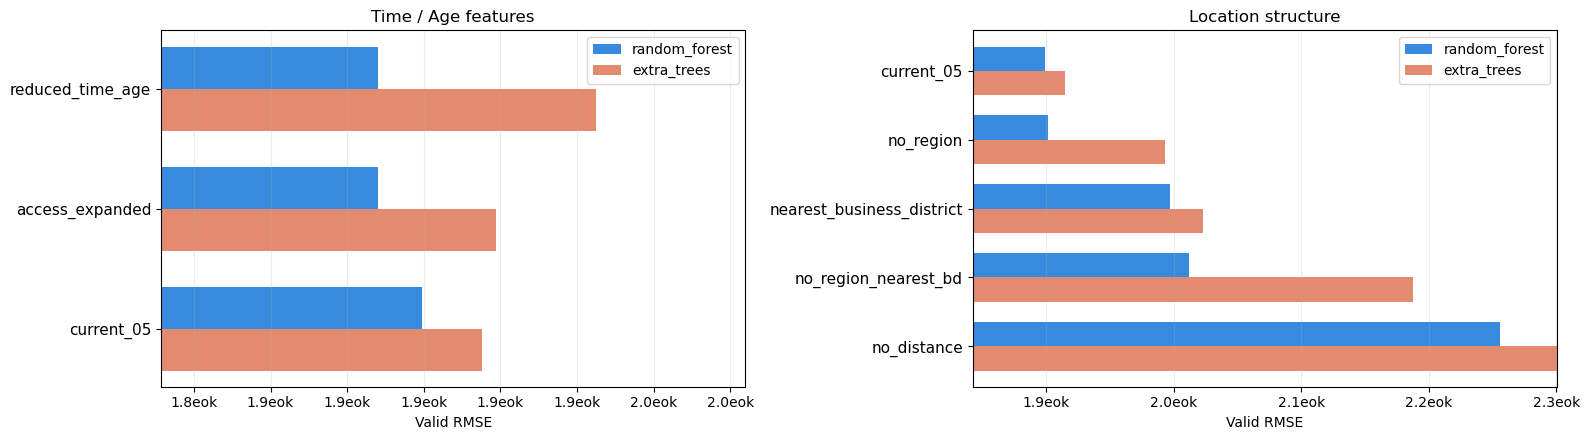

In [66]:
feature_score_df = pd.DataFrame(feature_score_rows).sort_values('valid_rmse').reset_index(drop=True)
feature_score_df.to_csv(FEATURE_SET_SCORE_PATH, index=False, encoding='utf-8-sig')
print(f'feature set scores saved: {FEATURE_SET_SCORE_PATH}')
display(feature_score_df)

time_df = feature_score_df[feature_score_df['group'] == 'time'].copy()
baseline_df = feature_score_df[feature_score_df['feature_set'] == 'current_05'].copy()
baseline_df['group'] = 'location'
location_df = pd.concat([
    baseline_df,
    feature_score_df[feature_score_df['group'] == 'location'],
]).drop_duplicates('feature_set')

group_dfs = [time_df, location_df]
titles = ['Time / Age features', 'Location structure']
et_all = feature_score_df[feature_score_df['model'] == 'extra_trees'].set_index('feature_set')['valid_rmse']

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, 5 * 0.9)), sharey=False)

for i, (gdf, title) in enumerate(zip(group_dfs, titles)):
    ax = axes[i]
    rf = gdf[gdf['model'] == 'random_forest'].sort_values('valid_rmse', ascending=False)
    order = rf['feature_set'].tolist()

    y = np.arange(len(order))
    h = 0.35

    bar_rf = ax.barh(y + h/2, rf['valid_rmse'].values, height=h, color='#378ADD', label='random_forest')
    bar_et = ax.barh(y - h/2, [et_all[f] for f in order], height=h, color='#D85A30', alpha=0.7, label='extra_trees')

    ax.set_yticks(y)
    ax.set_yticklabels(order, fontsize=11)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/10000:.1f}eok'))
    ax.set_xlim(gdf['valid_rmse'].min() * 0.97, gdf['valid_rmse'].max() * 1.02)
    ax.set_xlabel('Valid RMSE')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)
    ax.legend(handles=[bar_rf, bar_et], fontsize=10)

fig.tight_layout()
display(fig)
plt.close(fig)

### 5-1. 변수 조합 비교 결과 해석

**시간/연식 변수 조합(3-A)**

RandomForest 기준으로는 `reduced_time_age`가 검증 RMSE 18,880으로 1위를 기록했으나,
ExtraTrees에서는 순위가 역전되어 `current_05`가 가장 낮은 RMSE를 보였다.
두 모델 간 성능 차이가 일관되지 않아 시간/연식 변수 조정의 효과가 모델에 따라 다르게 나타났다.
또한 모든 조합에서 RandomForest가 ExtraTrees보다 낮은 RMSE를 기록했다.
RF 기준으로 튜닝 대상을 선정하므로 `reduced_time_age`를 채택한다.

**위치 변수 구조 조합(3-B)**

`no_distance`는 두 모델 모두에서 성능이 크게 하락했다. 거리 변수를 행정구역 변수로
완전히 대체할 수 없으며, 거리 변수가 독립적인 위치 정보를 제공하고 있음을 확인했다.
`no_region`은 두 모델 모두에서 `current_05`와 근접한 성능을 보였다. 거리 변수와
행정구역 변수가 상당 부분 중복 정보를 담고 있는 것으로 해석된다.
위 두 결과를 종합하면, 두 변수군은 서로 다른 정보를 보완적으로 담고 있으며
함께 사용하는 것이 최선임을 확인했다. 3-B에서도 모든 조합에서 RandomForest가
ExtraTrees보다 낮은 RMSE를 기록했다.

이를 바탕으로 섹션 6에서 각 그룹의 최선 조합을 비교해 튜닝 대상을 확정한다.

## 6. 튜닝 대상 선정

3-A와 3-B 각 그룹에서 RandomForest 기준 최선 조합을 선정한 뒤,
두 결과를 비교해 최종 튜닝 대상을 확정한다.

In [65]:
# 각 그룹에서 RF 기준 최선 조합 선정
best_time = (
    feature_score_df[
        (feature_score_df['group'] == 'time') &
        (feature_score_df['model'] == 'random_forest')
    ]
    .sort_values('valid_rmse')
    .iloc[0]
)

best_location = (
    feature_score_df[
        (feature_score_df['group'] == 'location') &
        (feature_score_df['model'] == 'random_forest')
    ]
    .sort_values('valid_rmse')
    .iloc[0]
)

print(f'[3-A] best: {best_time["feature_set"]}  valid_rmse={best_time["valid_rmse"]:,.0f}')
print(f'[3-B] best: {best_location["feature_set"]}  valid_rmse={best_location["valid_rmse"]:,.0f}')

# 두 그룹 최선 조합 비교 후 튜닝 대상 확정
best_row = best_time if best_time['valid_rmse'] <= best_location['valid_rmse'] else best_location
best_feature_set = best_row['feature_set']
best_baseline_model = 'random_forest'
best_context = feature_set_frames[best_feature_set]
best_config = best_context['config']

print(f'\n튜닝 대상 변수 조합: {best_feature_set}')
print(f'기준 성능 최고 모델: {best_baseline_model}')
print(best_config['description'])

print('numeric_features:', best_config['numeric'])
print('categorical_features:', best_config['categorical'])

[3-A] best: reduced_time_age  valid_rmse=18,880
[3-B] best: no_region  valid_rmse=19,016

튜닝 대상 변수 조합: reduced_time_age
기준 성능 최고 모델: random_forest
단일 연도 자료에서 정보량이 낮은 contract_year와 중복 가능성이 있는 built_year, contract_day를 제외
numeric_features: ['area_m2', 'floor', 'age', 'contract_month', 'distance_to_cbd_km', 'distance_to_ybd_km', 'distance_to_gbd_km', 'nearest_subway_distance_km', 'nearest_hospital_distance_km', 'large_mart_count_within_1km']
categorical_features: ['gu', 'law_dong']


## 7. 하이퍼파라미터 탐색

선정된 모델과 변수 조합을 대상으로 하이퍼파라미터를 탐색한다.
 계산 시간 제약으로 전체 후보 조합 중 N_ITER=12개를 중복 없이 샘플링하며,
 각 파라미터 조합을 검증 세트에서 직접 평가해 RMSE가 낮은 조합을 선택한다.
 5단계 변수 조합 선택과 동일한 기준(X_valid)을 사용하므로 선택 기준이 일관된다.
 최종 테스트셋은 탐색에 사용하지 않는다.


In [55]:
train_df = best_context['train_df']
valid_df = best_context['valid_df']
test_df = best_context['test_df']

X_train = best_context['X_train']
y_train = best_context['y_train']
X_valid = best_context['X_valid']
y_valid = best_context['y_valid']

param_grid = {
    'n_estimators': [120, 180, 240],
    'max_depth': [12, 18, 24, None],
    'min_samples_leaf': [1, 2, 3, 5],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.7, 1.0],
}

len(train_df), len(valid_df), len(test_df)

(51986, 17197, 8154)

In [56]:
all_param_candidates = list(ParameterGrid(param_grid))
rng = np.random.default_rng(RANDOM_STATE)
candidate_indices = rng.choice(
    len(all_param_candidates),
    size=min(N_ITER, len(all_param_candidates)),
    replace=False,
)
param_list = [all_param_candidates[index] for index in candidate_indices]

tuning_rows = []
for i, params in enumerate(param_list):
    m = make_model(best_baseline_model, best_config['numeric'], best_config['categorical'], params)
    m.fit(X_train, y_train)
    pred = m.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, pred))
    tuning_rows.append({'params': params, 'valid_rmse': valid_rmse})
    print(f'[{i + 1:>2}/{N_ITER}] valid_rmse={valid_rmse:,.0f}  params={params}')

tuning_result_df = (
    pd.DataFrame(tuning_rows)
    .sort_values('valid_rmse')
    .reset_index(drop=True)
)

tuning_result_df.to_csv(TUNING_RESULT_PATH, index=False, encoding='utf-8-sig')
print(f'\n튜닝 결과 저장: {TUNING_RESULT_PATH}')
tuning_result_df.head()


[ 1/12] valid_rmse=18,915  params={'max_depth': 18, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 120}
[ 2/12] valid_rmse=23,247  params={'max_depth': 12, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 120}
[ 3/12] valid_rmse=17,693  params={'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 240}
[ 4/12] valid_rmse=18,841  params={'max_depth': 24, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 180}
[ 5/12] valid_rmse=19,060  params={'max_depth': 24, 'max_features': 0.7, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 120}
[ 6/12] valid_rmse=17,542  params={'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 240}
[ 7/12] valid_rmse=23,171  params={'max_depth': 12, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 180}
[

,params,valid_rmse
0,"{'max_depth': None, 'max_features': 0.7, 'min_...",17542.369237
1,"{'max_depth': None, 'max_features': 'sqrt', 'm...",17693.260735
2,"{'max_depth': 24, 'max_features': 1.0, 'min_sa...",18075.771190
3,"{'max_depth': 18, 'max_features': 1.0, 'min_sa...",18253.610779
4,"{'max_depth': 24, 'max_features': 'sqrt', 'min...",18840.516577


## 8. 검증 기준 최종 모델 선택

선정된 모델에서 검증 RMSE가 가장 낮은 하이퍼파라미터를 확정한다. 테스트 세트는 이 선택 이후에만 사용한다.

In [57]:
best_row = tuning_result_df.loc[0]
best_params = best_row['params']

print(f'최종 선택 모델    : {best_baseline_model}')
print(f'최종 선택 변수 조합: {best_feature_set}')
print(f'최종 하이퍼파라미터: {best_params}')
print(f'검증 RMSE (X_valid 직접 평가): {best_row["valid_rmse"]:,.0f} 만원')


최종 선택 모델    : random_forest
최종 선택 변수 조합: reduced_time_age
최종 하이퍼파라미터: {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 240}
검증 RMSE (X_valid 직접 평가): 17,542 만원


## 9. 최종 모델 학습 및 테스트 성능 검증

검증 RMSE 기준으로 최종 모델을 선택한 뒤, 학습 세트와 검증 세트를 합쳐 재학습하고 테스트 세트에서 성능을 확인한다. 테스트 결과는 최종 모델 선택 기준으로 사용하지 않는다.

In [58]:
# train + valid 합쳐서 최종 재학습
X_train_final = pd.concat([X_train, X_valid])
y_train_final = pd.concat([y_train, y_valid])

X_test = best_context['test_df'][best_config['numeric'] + best_config['categorical']]
y_test = best_context['test_df'][target_col]

final_model = make_model(best_baseline_model, best_config['numeric'], best_config['categorical'], best_params)
final_model.fit(X_train_final, y_train_final)

test_pred = final_model.predict(X_test)
test_scores = evaluate_regression(y_test, test_pred)

final_score_df = pd.DataFrame([{
    'feature_set': best_feature_set,
    'model': best_baseline_model,
    'params': str(best_params),
    'test_mae': test_scores['mae'],
    'test_rmse': test_scores['rmse'],
    'test_r2': test_scores['r2'],
}])

final_score_df.to_csv(FINAL_SCORE_PATH, index=False, encoding='utf-8-sig')
print(f'최종 모델 성능 저장: {FINAL_SCORE_PATH}')
final_score_df

최종 모델 성능 저장: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\reports\06_final_model_scores.csv


,feature_set,model,params,test_mae,test_rmse,test_r2
0,reduced_time_age,random_forest,"{'max_depth': None, 'max_features': 0.7, 'min_...",9341.210657,17364.705397,0.963874


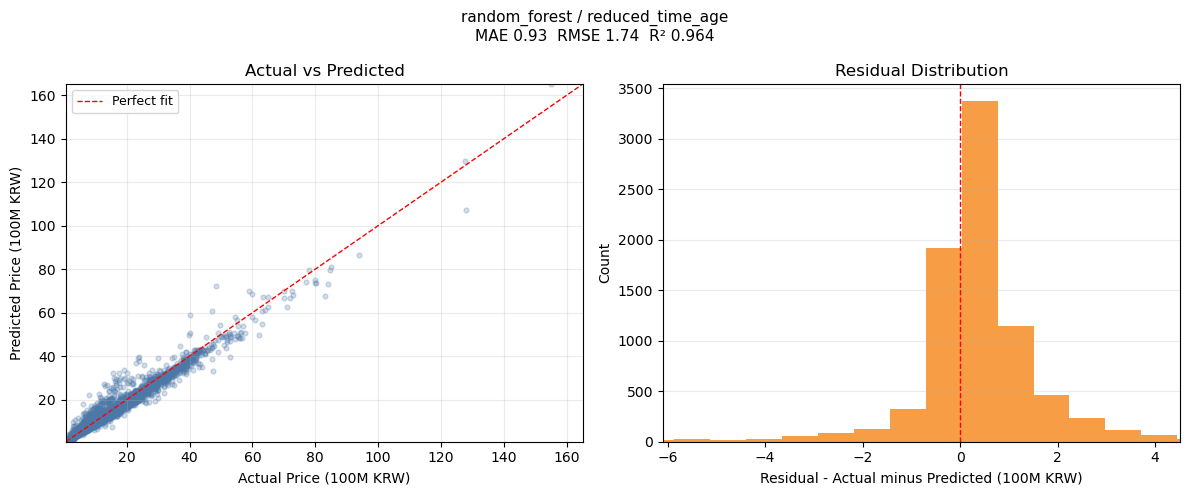

In [59]:
# 시각화용 금액 단위는 1억 원으로 함
y_test_eok = y_test.values / 10_000
test_pred_eok = test_pred / 10_000
residuals_eok = y_test_eok - test_pred_eok
mae_eok = test_scores['mae'] / 10_000
rmse_eok = test_scores['rmse'] / 10_000

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted 산점도
ax = axes[0]
lim = [
    min(float(y_test_eok.min()), float(test_pred_eok.min())),
    max(float(y_test_eok.max()), float(test_pred_eok.max())),
]
ax.scatter(y_test_eok, test_pred_eok, alpha=0.25, s=12, color='#4C78A8')
ax.plot(lim, lim, 'r--', linewidth=1, label='Perfect fit')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.ticklabel_format(style='plain', axis='both', useOffset=False)
ax.set_xlabel('Actual Price (100M KRW)')
ax.set_ylabel('Predicted Price (100M KRW)')
ax.set_title('Actual vs Predicted')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# 잔차 분포 히스토그램
ax = axes[1]
ax.hist(residuals_eok, bins=60, color='#F58518', alpha=0.8, edgecolor='none')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
residual_xlim = np.percentile(residuals_eok, [1, 99])
if residual_xlim[0] < residual_xlim[1]:
    ax.set_xlim(residual_xlim)
ax.ticklabel_format(style='plain', axis='x', useOffset=False)
ax.set_xlabel('Residual - Actual minus Predicted (100M KRW)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')
ax.grid(axis='y', alpha=0.25)

fig.suptitle(
    f'{best_baseline_model} / {best_feature_set}\n'
    f'MAE {mae_eok:,.2f}  RMSE {rmse_eok:,.2f}  R\u00b2 {test_scores["r2"]:.3f}',
    fontsize=11,
)
fig.tight_layout()
display(fig)
fig.savefig(FINAL_FIGURE_DIR / '06_final_model_test_performance.png', dpi=150, bbox_inches='tight')
plt.close(fig)


## 10. 최종 모델 확정 및 변수 중요도

검증 RMSE 기준으로 확정한 최종 모델의 변수 중요도를 확인한다. 변수 중요도는 모델 해석을 위한 보조 지표이며, 인과 효과로 해석하지 않는다.

In [60]:
importance_model = final_model.named_steps['model']
importance_values = importance_model.feature_importances_
all_features = best_config['numeric'] + best_config['categorical']

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importance_values,
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df.to_csv(FINAL_IMPORTANCE_PATH, index=False, encoding='utf-8-sig')
print(f'변수 중요도 저장: {FINAL_IMPORTANCE_PATH}')
importance_df

변수 중요도 저장: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\reports\06_final_model_feature_importance.csv


,feature,importance
0,distance_to_gbd_km,0.336583
1,area_m2,0.286864
2,age,0.092369
3,distance_to_cbd_km,0.069503
4,gu,0.058989
5,distance_to_ybd_km,0.057168
6,law_dong,0.023515
7,nearest_hospital_distance_km,0.021586
8,nearest_subway_distance_km,0.017660
9,contract_month,0.012146


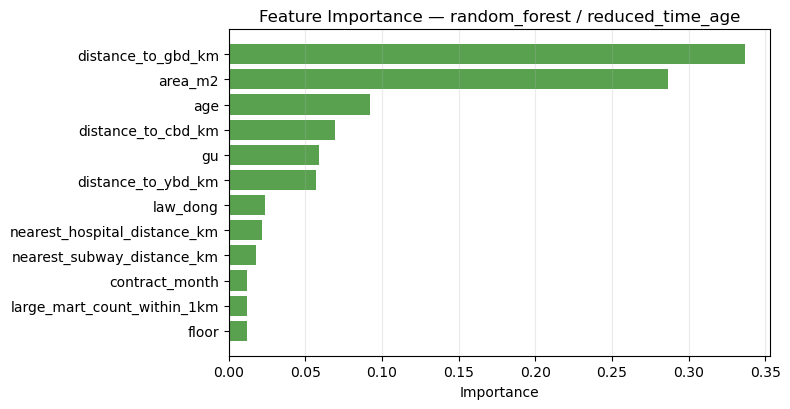

In [61]:
fig, ax = plt.subplots(figsize=(8, max(4, len(importance_df) * 0.35)))

plot_df = importance_df.sort_values('importance')
ax.barh(plot_df['feature'], plot_df['importance'], color='#59A14F')
ax.set_xlabel('Importance')
ax.set_title(f'Feature Importance — {best_baseline_model} / {best_feature_set}')
ax.grid(axis='x', alpha=0.25)

fig.tight_layout()
display(fig)
fig.savefig(FINAL_FIGURE_DIR / '06_final_model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.close(fig)

## 11. 진행사항 정리 및 다음 작업

### 이 노트북에서 수행한 내용

**변수 조합 비교**

시간/연식 변수 조합(3-A)과 위치 변수 구조 조합(3-B)으로 실험을 분리해 평가했다.
각 그룹에서 RandomForest 기준 최선 조합을 선정한 뒤 비교한 결과,
`reduced_time_age` 조합(수치형 10개, 범주형 2개)이 최종 튜닝 대상으로 확정됐다.

**하이퍼파라미터 탐색**

N_ITER=12개 조합을 검증 세트에서 직접 평가했다.
변수 조합 선택과 동일한 기준(X_valid)을 사용해 선택 기준을 통일했다.
최종 파라미터: n_estimators=240, max_depth=None, min_samples_leaf=1,
min_samples_split=5, max_features=0.7

**최종 모델 학습 및 테스트 평가**

train+valid를 합쳐 재학습 후 테스트 세트(11~12월)에서 성능을 확인했다.

| 지표 | 값 |
|------|-----|
| MAE  | 9,341만원 (약 0.93억) |
| RMSE | 17,365만원 (약 1.74억) |
| R²   | 0.964 |

테스트 세트는 어떤 선택 기준에도 사용하지 않았다.

<br/>

---

### 확인된 사항 및 한계

변수 중요도에서 `distance_to_gbd_km`(0.337)과 `area_m2`(0.287)
두 변수가 전체 중요도의 약 62%를 차지한다.
R² 0.964라는 높은 수치가 이 두 변수의 강한 신호에 주로 기인할 가능성이 있으며,
모델이 서울 아파트 시장의 복잡한 구조를 전반적으로 학습했다고 단언하기 어렵다.

선정된 파라미터(min_samples_leaf=1, max_depth=None, max_features=0.7)는
RandomForest로서 과적합 쪽에 가까운 설정이다.
N_ITER=12라는 제한된 탐색 횟수로 인해 탐색 공간을 충분히 커버하지 못했을 수 있다.

<br/>

---

### 다음 작업

- **모델 해석 보완**: 변수 중요도 편중이 실제 데이터 구조에서 비롯된 것인지
  확인하기 위해 Permutation Importance 또는 부분 의존성 플롯(PDP)을 검토한다.
- **탐색 강화 보류**: N_ITER=12는 제한적이나, 해석 보완 결과에 따라
  탐색 심화 여부를 결정한다.